<a href="https://colab.research.google.com/github/HKozuka/IDX-Exchange-Data-Science/blob/main/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IDX Exchange Internship - Data Exploration**

In [33]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load and Merge 28 Monthly California Regional MLS Files (Jan 2024 to Apr 2026)

In [42]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Path to the directory on your Google Drive
target_directory = '/content/drive/MyDrive/IDX Exchange Data Science Internship/Google Colab Notebooks'

# Search for CSV files in that folder
csv_files = glob.glob(os.path.join(target_directory, '*.csv'))
print(f"Found {len(csv_files)} CSV files in the directory.\n")

# Dictionary to hold the dataframes
dataframes = {}

# Load each file into the dictionary
for file_path in csv_files:
    file_name = os.path.basename(file_path)
    name = os.path.splitext(file_name)[0]
 #   try:
 #       dataframes[name] = pd.read_csv(file_path)
 #       print(f"Successfully loaded: {file_name} as dataframes['{name}']")
 #   except Exception as e:
 #       print(f"Error loading {file_name}: {e}")

Found 28 CSV files in the directory.



In [35]:
# Print a summary of the loaded DataFrames
print(f"Total loaded DataFrames: {len(dataframes)}\n")
print(f"{'DataFrame Name':<30} | {'Rows':<8} | {'Columns':<8}")
print("-" * 54)
for name, df in sorted(dataframes.items()):
    print(f"{name:<30} | {df.shape[0]:<8} | {df.shape[1]:<8}")

Total loaded DataFrames: 28

DataFrame Name                 | Rows     | Columns 
------------------------------------------------------
CRMLSSold202401_filled         | 17958    | 80      
CRMLSSold202402                | 19925    | 78      
CRMLSSold202403_filled         | 23276    | 80      
CRMLSSold202404_filled         | 24640    | 80      
CRMLSSold202405_filled         | 26487    | 80      
CRMLSSold202406_filled         | 24328    | 80      
CRMLSSold202407_filled         | 26240    | 80      
CRMLSSold202408                | 24558    | 78      
CRMLSSold202409                | 21267    | 78      
CRMLSSold202410                | 23274    | 78      
CRMLSSold202411                | 20279    | 78      
CRMLSSold202412                | 20241    | 78      
CRMLSSold202501_filled         | 18738    | 80      
CRMLSSold202502                | 18702    | 78      
CRMLSSold202503                | 21445    | 78      
CRMLSSold202504                | 23262    | 78      
CRMLSSold202505

In [36]:
# Inspect the differences in columns across the datasets
# Compare a 80-column dataset with a 78-column dataset

df_80_key = 'CRMLSSold202401_filled'
df_78_key = 'CRMLSSold202402'

if df_80_key in dataframes and df_78_key in dataframes:
    cols_80 = set(dataframes[df_80_key].columns)
    cols_78 = set(dataframes[df_78_key].columns)

    extra_cols = cols_80 - cols_78
    missing_cols = cols_78 - cols_80

    print(f"Columns in '{df_80_key}' but NOT in '{df_78_key}': {extra_cols}")
    print(f"Columns in '{df_78_key}' but NOT in '{df_80_key}': {missing_cols}\n")

# Display preview of the first loaded dataset
first_dataset_name = sorted(list(dataframes.keys()))[0]
print(f"--- Preview of {first_dataset_name} ---")
dataframes[first_dataset_name].head()

Columns in 'CRMLSSold202401_filled' but NOT in 'CRMLSSold202402': {'latfilled', 'lonfilled'}
Columns in 'CRMLSSold202402' but NOT in 'CRMLSSold202401_filled': set()

--- Preview of CRMLSSold202401_filled ---


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,NaN,False,1.0,Other,94401,6472.0,NaN,NaN,True,True
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,NaN,NaN,NaN,92394,NaN,52320.0,NaN,False,False
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,False,NaN,NaN,93240,NaN,217364.0,NaN,False,False
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,False,NaN,NaN,92308,NaN,217800.0,NaN,False,False
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,NaN,False,NaN,NaN,93544,0.0,108883.0,NaN,False,False


In [37]:
# Combine all loaded DataFrames into a single master DataFrame
print("Concatenating all 28 DataFrames...")
merged_df = pd.concat(dataframes.values(), ignore_index=True)

print(f"Successfully created master DataFrame 'merged_df'!")
print(f"Total Rows: {merged_df.shape[0]:,}")
print(f"Total Columns: {merged_df.shape[1]}")

# Let's inspect the distribution of our missing/filled geolocation columns
if 'latfilled' in merged_df.columns:
    print("\nDistribution of 'latfilled' in the merged dataset:")
    print(merged_df['latfilled'].value_counts(dropna=False))

Concatenating all 28 DataFrames...
Successfully created master DataFrame 'merged_df'!
Total Rows: 615,707
Total Columns: 84

Distribution of 'latfilled' in the merged dataset:
latfilled
NaN      454040
False    102518
True      59149
Name: count, dtype: int64


### This notebook focuses on initial exploration. Missing value handling, preprocessing, transformations, and feature engineering are deferred to "Week 3 - Data Preprocessing."

## Filter to Single Family Residencial Listings Only

In [38]:
# 1. Filter the merged dataset to restrict to Residential Single Family Residence listings
filtered_df = merged_df[
    (merged_df['PropertyType'] == 'Residential') &
    (merged_df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f"Successfully filtered dataset!")
print(f"Original rows: {len(merged_df):,}")
print(f"Filtered rows (Residential & SingleFamilyResidence): {len(filtered_df):,}")

Successfully filtered dataset!
Original rows: 615,707
Filtered rows (Residential & SingleFamilyResidence): 309,735


Dataset has gone from 615k rows to 309k rows.

## Distribution of ClosePrice - The Target Variable

In [39]:
# Min and Max ClosePrice
min(filtered_df['ClosePrice']), max(filtered_df['ClosePrice'])

(0.0, 989500000.0)

Min close price **\$0**,
Max close price **\$989.5M**

## Outlier Removal
Values outside the 0.5th to 99.5th percentiles are removed, following the [Internship Best Practices Doc](https://drive.google.com/file/d/1Gr9n3-HoqYT5mKvU8UxmceMq4jJpQsTT/view). These thresholds may be adjusted later to better fit this dataset.

0.5th Percentile: $190,000.00
99.5th Percentile: $8,498,340.00

Properties with ClosePrice between the 0.5th and 99.5th percentile:
306,663 properties out of 309,735 (99.01% of data)



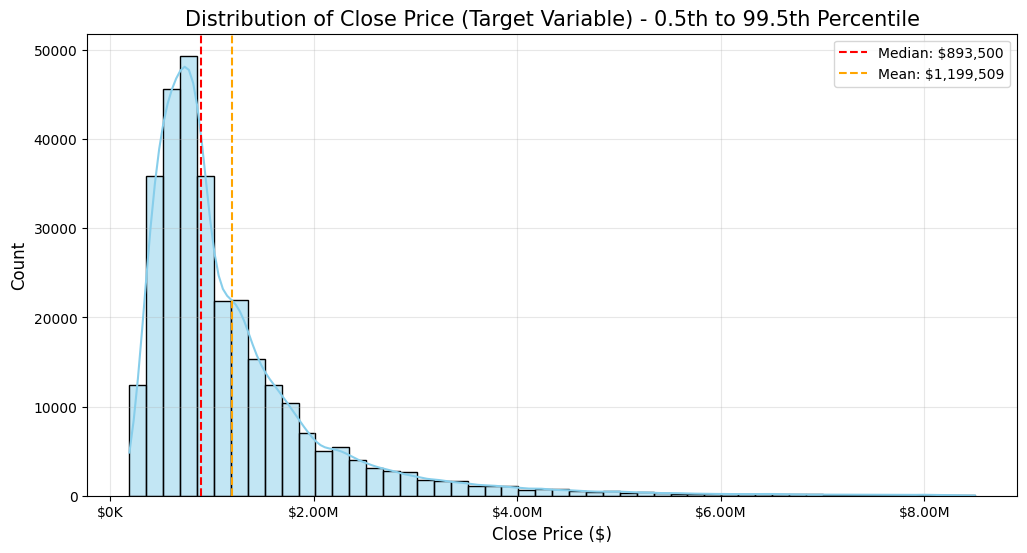

Skewness of close prices: 2.77


In [40]:
# Calculate the 0.5th and 99.5th percentiles of ClosePrice
min_price = filtered_df['ClosePrice'].quantile(0.005)
max_price = filtered_df['ClosePrice'].quantile(0.995)

cleaned_prices = filtered_df[
    (filtered_df['ClosePrice'] >= min_price) &
    (filtered_df['ClosePrice'] <= max_price)
]['ClosePrice']

print(f"0.5th Percentile: ${min_price:,.2f}")
print(f"99.5th Percentile: ${max_price:,.2f}\n")
print(f"Properties with ClosePrice between the 0.5th and 99.5th percentile:")
print(f"{len(cleaned_prices):,} properties out of {len(filtered_df):,} ({len(cleaned_prices)/len(filtered_df)*100:.2f}% of data)\n")

# Plotting the target variable distribution
plt.figure(figsize=(12, 6))
sns.histplot(cleaned_prices, bins=50, kde=True, color='skyblue')

# Formatting labels and title
plt.title('Distribution of Close Price (Target Variable) - 0.5th to 99.5th Percentile', fontsize=15)
plt.xlabel('Close Price ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(cleaned_prices.median(), color='red', linestyle='--', label=f'Median: ${cleaned_prices.median():,.0f}')
plt.axvline(cleaned_prices.mean(), color='orange', linestyle='--', label=f'Mean: ${cleaned_prices.mean():,.0f}')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x*1e-6:.2f}M' if x >= 1e6 else f'${x*1e-3:.0f}K'))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Skewness of close prices: {cleaned_prices.skew():.2f}")

# Distribution of LivingArea, Bedrooms, Bathrooms, and LotSize

Detected bathroom-related columns in dataset: ['BathroomsTotalInteger']
Features mapping to find in dataset: {'LivingArea': 'LivingArea', 'Bedrooms': 'BedroomsTotal', 'Bathrooms': 'BathroomsTotalInteger', 'LotSize': 'LotSizeSquareFeet'}
LivingArea (LivingArea):
  Range: 638.0 to 6,745.3
  Retained: 306,474 non-null values (99.00% of non-null records)

Bedrooms (BedroomsTotal):
  Range: 1.0 to 6.0
  Retained: 308,057 non-null values (99.46% of non-null records)

Bathrooms (BathroomsTotalInteger):
  Range: 1.0 to 7.0
  Retained: 308,314 non-null values (99.56% of non-null records)

LotSize (LotSizeSquareFeet):
  Range: 1,356.0 to 477,669.9
  Retained: 301,362 non-null values (99.00% of non-null records)



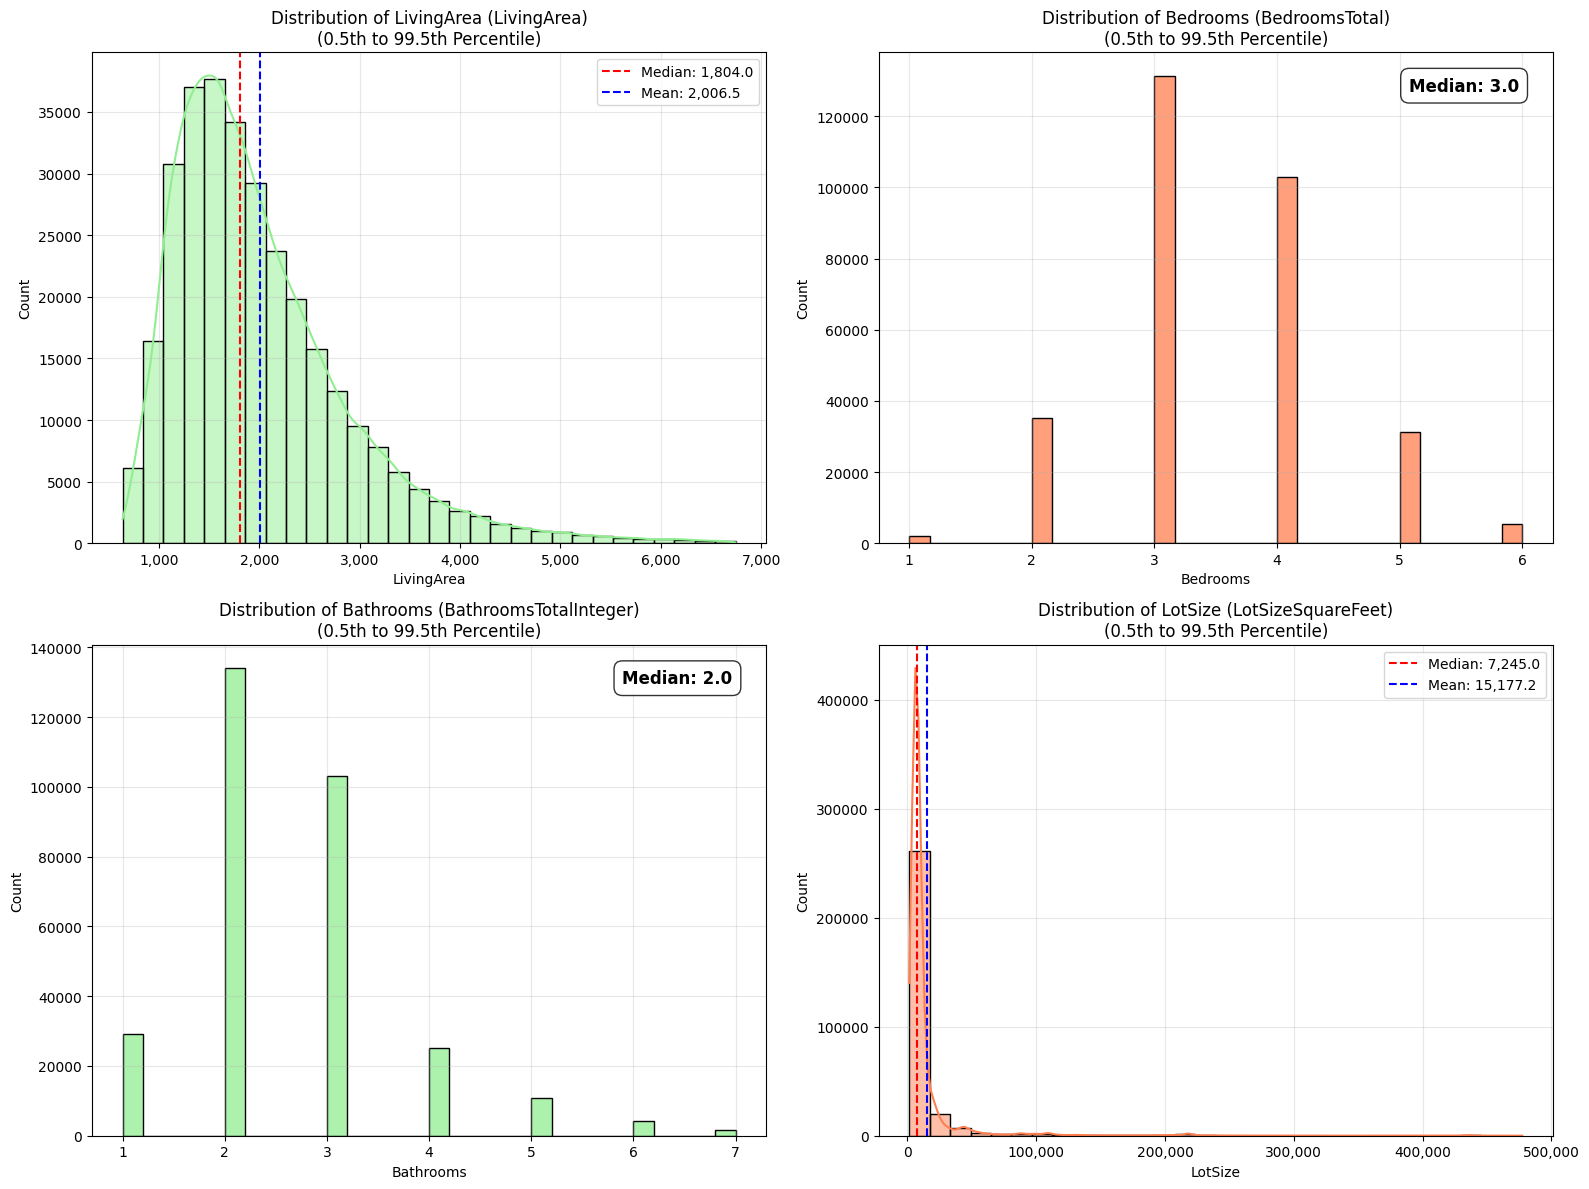

In [41]:
# Find any column matching 'bath' to dynamically map the right Bathroom column (preserving case-sensitivity)
bath_cols = [col for col in filtered_df.columns if 'bath' in col.lower()]
print("Detected bathroom-related columns in dataset:", bath_cols)

bath_col_to_use = None
# Find the exact case-sensitive column name that matches our preferred candidates
for preferred in ['bathroomstotalvalue', 'bathroomstotal', 'bathroomsfull', 'bathrooms', 'bathroomstotalinteger']:
    matched = [c for c in bath_cols if c.lower() == preferred]
    if matched:
        bath_col_to_use = matched[0]
        break

if not bath_col_to_use and bath_cols:
    bath_col_to_use = bath_cols[0]

feature_mapping = {
    'LivingArea': 'LivingArea' if 'LivingArea' in filtered_df.columns else ('BuildingAreaTotal' if 'BuildingAreaTotal' in filtered_df.columns else None),
    'Bedrooms': 'BedroomsTotal' if 'BedroomsTotal' in filtered_df.columns else None,
    'Bathrooms': bath_col_to_use,
    'LotSize': 'LotSizeSquareFeet' if 'LotSizeSquareFeet' in filtered_df.columns else None
}

active_features = {k: v for k, v in feature_mapping.items() if v is not None}
print("Features mapping to find in dataset:", active_features)

# Set up a subplot grid for the distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (display_name, col_name) in enumerate(active_features.items()):
    data_series = filtered_df[col_name].dropna()
    min_val = data_series.quantile(0.005)
    max_val = data_series.quantile(0.995)

    cleaned_series = data_series[
        (data_series >= min_val) &
        (data_series <= max_val)
    ]

    # Disable KDE distribution curves specifically for Bedrooms and Bathrooms
    is_discrete = display_name in ['Bedrooms', 'Bathrooms']
    use_kde = not is_discrete

    # Plot histogram
    sns.histplot(cleaned_series, bins=30, kde=use_kde, ax=axes[i], color='lightgreen' if i%2==0 else 'coral')

    if is_discrete:
        # Clearly indicate the median as text in the upper right corner of the graph
        axes[i].text(0.95, 0.95, f'Median: {cleaned_series.median():.1f}',
                     transform=axes[i].transAxes, fontsize=12, fontweight='bold',
                     verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    else:
        # Retain lines for continuous variables (LivingArea and LotSize)
        axes[i].axvline(cleaned_series.median(), color='red', linestyle='--', label=f'Median: {cleaned_series.median():,.1f}')
        axes[i].axvline(cleaned_series.mean(), color='blue', linestyle='--', label=f'Mean: {cleaned_series.mean():,.1f}')
        axes[i].legend()

    axes[i].set_title(f'Distribution of {display_name} ({col_name})\n(0.5th to 99.5th Percentile)', fontsize=12)
    axes[i].set_xlabel(display_name, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].grid(True, alpha=0.3)

    axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

    print(f"{display_name} ({col_name}):")
    print(f"  Range: {min_val:,.1f} to {max_val:,.1f}")
    print(f"  Retained: {len(cleaned_series):,} non-null values ({len(cleaned_series)/len(data_series)*100:.2f}% of non-null records)\n")

plt.tight_layout()
plt.show()


### Summary of Key Findings

Based on the initial exploratory data analysis (filtered to single-family residential properties and removing outliers below the $0.5^{\text{th}}$ and above the $99.5^{\text{th}}$ percentiles across 28 aggregated CSV datasets), here are the updated main insights:

* **Close Price (The Target Variable):**
  * Highly right-skewed with a median price of **\$893,500** and a mean of **\$1,199,509**.
  * Truncated range for analysis spans from **\$190,000** to **\$8,498,340**.
  * Skewness score is **2.77**.

* **Living Area (`LivingArea`):**
  * Displays a typical right-skewed log-normal-like distribution.
  * Standard single-family residence size centers around a median of **1,804 sq. ft.** (mean of **2,006.5 sq. ft.**), extending up to **6,745.3 sq. ft.**

* **Bedrooms (`BedroomsTotal`) & Bathrooms (`BathroomsTotalInteger`):**
  * The vast majority of properties feature exactly **3 bedrooms** and **2 bathrooms**.

* **Lot Size (`LotSizeSquareFeet`):**
  * *Exceptionally heavy right-skew* with a median lot size of **7,245.0 sq. ft.** but a significantly higher mean of **15,177.2 sq. ft.** driven by expansive properties on the upper end (up to **477,669.9 sq. ft.**).